Gewähltes Anwendungsszenario

Road Traffic

Aufgabe A.

Bestimmen Sie Lage und Streuung aller Merkmale inkl. Zielvariablen. Die Parameter für Lage
und Streuung sind selbst zu wählen. Welche zwei Merkmale sind sich bzgl. Lage und Streuung
am ähnlichsten bzw. am unähnlichsten? Sollte der Datensatz standardisiert werden?
Begründen Sie.

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("traffic-prediction-dataset.csv")
df.columns = [c.strip() for c in df.columns]

stats = pd.DataFrame({
    "mean": df.mean(numeric_only=True),
    "median": df.median(numeric_only=True),
    "q1": df.quantile(0.25, numeric_only=True),
    "q3": df.quantile(0.75, numeric_only=True),
    "std": df.std(numeric_only=True),
    "var": df.var(numeric_only=True),
    "min": df.min(numeric_only=True),
    "max": df.max(numeric_only=True),
})

stats["range"] = stats["max"] - stats["min"]
stats["iqr"] = stats["q3"] - stats["q1"]

stats = stats[["mean", "median", "q1", "q3", "std", "var", "range", "iqr"]]
stats.round(3)

,mean,median,q1,q3,std,var,range,iqr
Cross 1,95.806,88.0,8.0,169.0,87.587,7671.433,352.5,161.0
Cross 2,45.948,29.0,2.0,77.0,50.865,2587.253,302.0,75.0
Cross 3,41.510,32.0,1.0,73.0,41.850,1751.388,218.0,72.0
Cross 4,67.657,45.0,0.0,124.0,68.536,4697.203,312.0,124.0
Cross 5,36.232,28.0,1.0,60.0,37.372,1396.700,193.0,59.0
Cross 6,76.215,66.0,5.0,139.0,68.102,4637.854,253.0,134.0


In [4]:
compare_cols = ["mean", "median", "std", "iqr"]
pairs = []

for i, c1 in enumerate(stats.index):
    for c2 in stats.index[i+1:]:
        d = np.linalg.norm(stats.loc[c1, compare_cols].values - stats.loc[c2, compare_cols].values)
        pairs.append((c1, c2, d))

pair_df = pd.DataFrame(pairs, columns=["feature_1", "feature_2", "distance"]).sort_values("distance")
pair_df.round(3)

,feature_1,feature_2,distance
5,Cross 2,Cross 3,10.908
10,Cross 3,Cross 5,15.261
7,Cross 2,Cross 5,23.097
13,Cross 4,Cross 6,24.788
4,Cross 1,Cross 6,44.458
6,Cross 2,Cross 4,58.656
9,Cross 3,Cross 4,65.336
2,Cross 1,Cross 4,66.131
8,Cross 2,Cross 6,77.866
12,Cross 4,Cross 5,80.453


In [5]:
most_similar = pair_df.iloc[0]
most_different = pair_df.iloc[-1]

print("Most similar:")
print(most_similar.to_string())
print()
print("Most different:")
print(most_different.to_string())

Most similar:
feature_1      Cross 2
feature_2      Cross 3
distance     10.907581

Most different:
feature_1       Cross 1
feature_2       Cross 5
distance     141.684525


Standardisierung wird empfohlen, da sich die Merkmale in ihrer Lage und Streuung unterscheiden.

Aufgabe B.

Visualisieren Sie die Merkmale nach einer Standardisierung (Die Methode ist selbst zu wählen)
in einem Boxplot. Vergleichen Sie die standardisierten Daten mit den originalen Daten. Was
fällt Ihnen auf?

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("traffic-prediction-dataset.csv")
df.columns = [c.strip() for c in df.columns]

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

print(df.describe().round(3))
print()
print(df_scaled.describe().round(3))

         Cross 1    Cross 2   Cross 3    Cross 4    Cross 5    Cross 6
count  16128.000  16128.000  16128.00  16128.000  16128.000  16128.000
mean      95.806     45.948     41.51     67.657     36.232     76.215
std       87.587     50.865     41.85     68.536     37.372     68.102
min        0.000      0.000      0.00      0.000      0.000      0.000
25%        8.000      2.000      1.00      0.000      1.000      5.000
50%       88.000     29.000     32.00     45.000     28.000     66.000
75%      169.000     77.000     73.00    124.000     60.000    139.000
max      352.500    302.000    218.00    312.000    193.000    253.000

         Cross 1    Cross 2    Cross 3    Cross 4    Cross 5    Cross 6
count  16128.000  16128.000  16128.000  16128.000  16128.000  16128.000
mean      -0.000      0.000      0.000     -0.000     -0.000      0.000
std        1.000      1.000      1.000      1.000      1.000      1.000
min       -1.094     -0.903     -0.992     -0.987     -0.970     -1.119


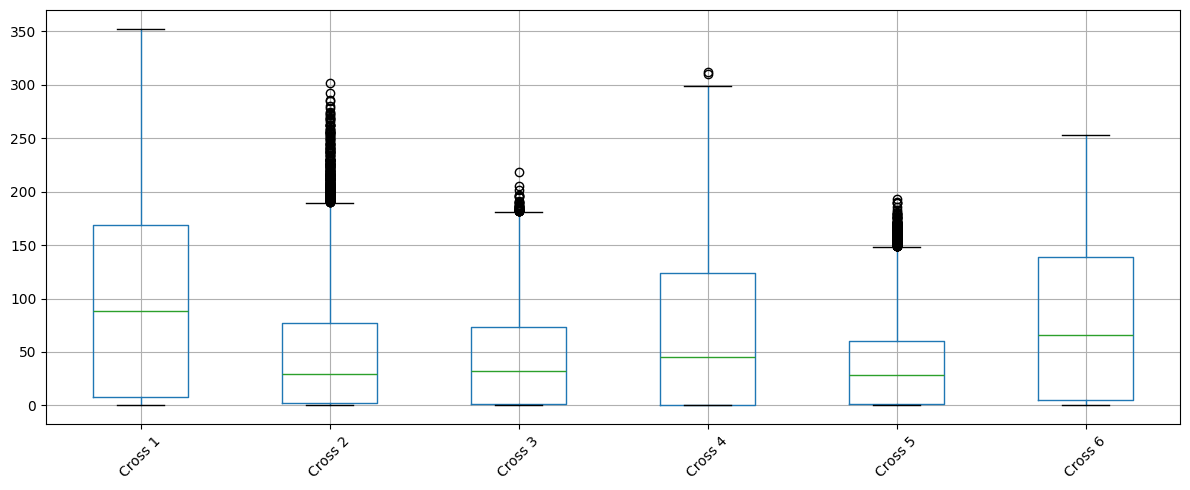

In [8]:
plt.figure(figsize=(12, 5))
df.boxplot(rot=45)
plt.tight_layout()
plt.show()

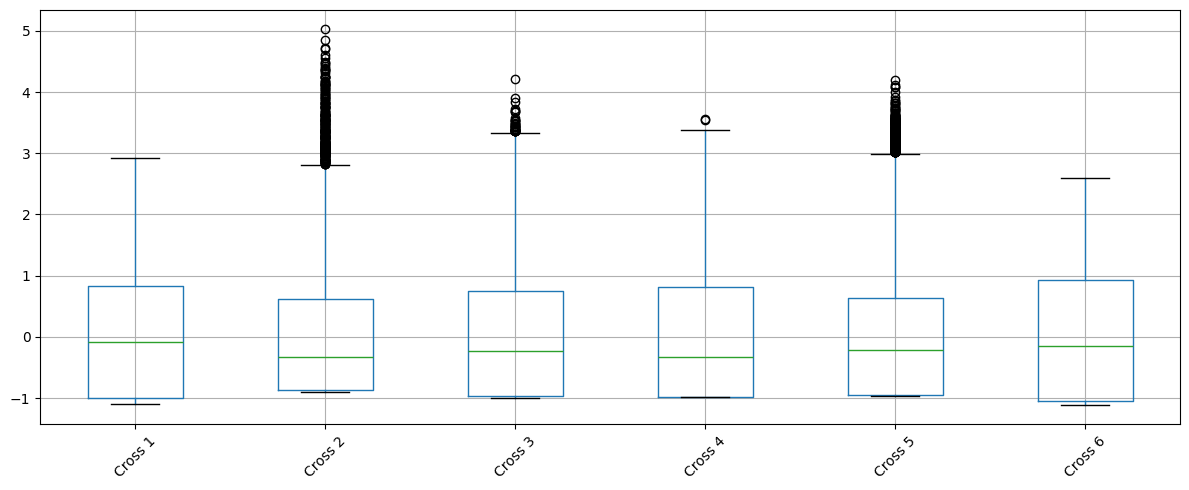

In [9]:
plt.figure(figsize=(12, 5))
df_scaled.boxplot(rot=45)
plt.tight_layout()
plt.show()

Nach der Standardisierung befinden sich die Merkmale auf derselben Skala.
Die Mediane rücken näher zusammen, die Streuungen werden direkt vergleichbar, und Ausreißer bleiben weiterhin sichtbar.